## Neural Networks - Deep Learning
**Theodora Tzina - AEM: 10715**
### Exercise 1
#### ***Part A: Preprocessing the CIFAR-10 dataset***

**Loading and Normalizing CIFAR-10 dataset:**

CIFAR-10 Classes
0: airplane
1: automobile
2: bird
3: cat
4: deer
5: dog
6: frog
7: horse
8: ship
9: truck

Loading and Normalizing CIFAR-10
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


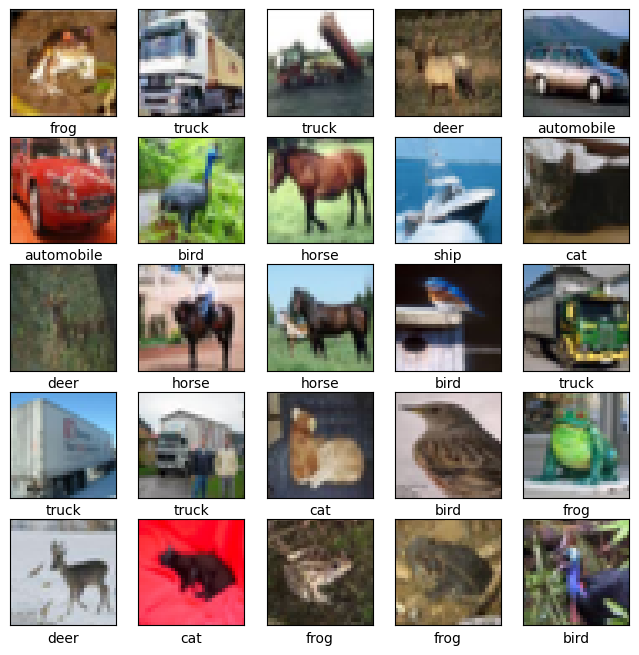

In [1]:
from dataProccessing import load_cifar10, flatten_cifar10, get_class_names, apply_pca
from kNearestNeighbors import train_knn, knn_results
from nearestClassCentroid import train_ncc, ncc_results
import matplotlib.pyplot as plt

# Load class names
class_names = get_class_names()

# Load and normalize CIFAR-10 dataset
x_train, y_train, x_test, y_test = load_cifar10()

# Visualize the first 25 images from the training set
plt.figure(figsize=(8,8))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i]])
plt.show()

**Flattening CIFAR-10 dataset:**

*--> Running this command only for kNN and NCC*

In [2]:
# Flatten CIFAR-10 images
x_train, x_test = flatten_cifar10(x_train, x_test)

Flattening CIFAR-10 images
Flattened training data shape: (50000, 3072)
Flattened test data shape: (10000, 3072)


**Applying Principal Component Analysis (PCA) to reduce principal components:**

*--> Running this command only when needed*

In [3]:
# Apply PCA to reduce dimensionality
n_components = 50
x_train, x_test, pca = apply_pca(x_train, x_test, n_components)

Applying PCA: 3072 → 50 dimensions
Explained variance: 84.30%
New training shape: (50000, 50)
New test shape: (10000, 50)


##### ***K-Nearest Neighbors for k=1 & k=3***
**Euclidean distance:**

K-Nearest Neighbors Classifier for k=1 and euclidean distance
Training time: 0.01 seconds
Testing time: 9.66 seconds
Training accuracy: 100.00%
Test accuracy: 39.07%


====== Classification Report (kNN for k=1, metric=euclidean) ======:
              precision    recall  f1-score   support

    airplane       0.45      0.52      0.48      1000
  automobile       0.56      0.36      0.44      1000
        bird       0.28      0.38      0.32      1000
         cat       0.32      0.24      0.27      1000
        deer       0.28      0.40      0.33      1000
         dog       0.40      0.31      0.34      1000
        frog       0.32      0.45      0.38      1000
       horse       0.50      0.39      0.44      1000
        ship       0.46      0.55      0.50      1000
       truck       0.54      0.32      0.40      1000

    accuracy                           0.39     10000
   macro avg       0.41      0.39      0.39     10000
weighted avg       0.41      0.39      0.39     10000



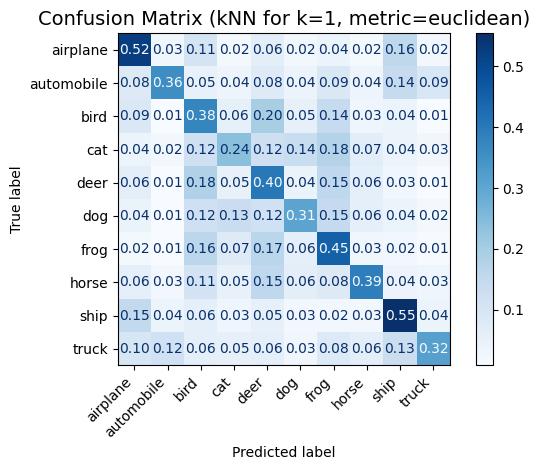

K-Nearest Neighbors Classifier for k=3 and euclidean distance
Training time: 0.00 seconds
Testing time: 6.27 seconds
Training accuracy: 63.37%
Test accuracy: 37.74%


====== Classification Report (kNN for k=3, metric=euclidean) ======:
              precision    recall  f1-score   support

    airplane       0.34      0.61      0.43      1000
  automobile       0.49      0.41      0.45      1000
        bird       0.24      0.46      0.32      1000
         cat       0.30      0.24      0.26      1000
        deer       0.28      0.39      0.33      1000
         dog       0.47      0.24      0.31      1000
        frog       0.39      0.38      0.39      1000
       horse       0.65      0.29      0.40      1000
        ship       0.53      0.53      0.53      1000
       truck       0.66      0.23      0.34      1000

    accuracy                           0.38     10000
   macro avg       0.44      0.38      0.38     10000
weighted avg       0.44      0.38      0.38     10000



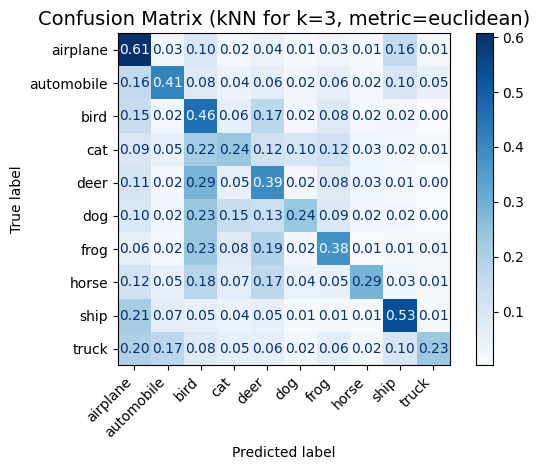

In [4]:
# K-Nearest Neighbors for k=1 and Euclidean distance
knn, y_pred_knn, test_accuracy_knn = train_knn(
    x_train, y_train, x_test, y_test, k=1, metric='euclidean')

knn_results(y_test, y_pred_knn, class_names, k=1, metric='euclidean')

# K-Nearest Neighbors for k=3 and Euclidean distance
knn_3, y_pred_knn_3, test_accuracy_knn_3 = train_knn(
    x_train, y_train, x_test, y_test, k=3, metric='euclidean')

knn_results(y_test, y_pred_knn_3, class_names, k=3, metric='euclidean')

**Cosine distance:**

K-Nearest Neighbors Classifier for k=1 and cosine distance
Training time: 0.01 seconds
Testing time: 26.95 seconds
Training accuracy: 100.00%
Test accuracy: 42.11%


====== Classification Report (kNN for k=1, metric=cosine) ======:
              precision    recall  f1-score   support

    airplane       0.49      0.56      0.52      1000
  automobile       0.50      0.46      0.48      1000
        bird       0.33      0.34      0.34      1000
         cat       0.27      0.27      0.27      1000
        deer       0.34      0.35      0.34      1000
         dog       0.38      0.35      0.36      1000
        frog       0.41      0.47      0.44      1000
       horse       0.53      0.45      0.49      1000
        ship       0.48      0.56      0.52      1000
       truck       0.50      0.39      0.44      1000

    accuracy                           0.42     10000
   macro avg       0.42      0.42      0.42     10000
weighted avg       0.42      0.42      0.42     10000



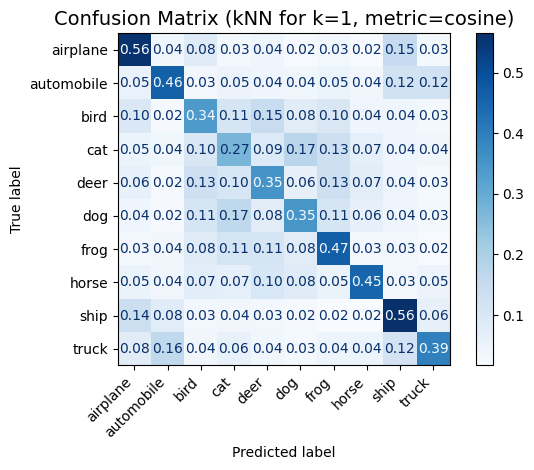

K-Nearest Neighbors Classifier for k=3 and cosine distance
Training time: 0.02 seconds
Testing time: 27.08 seconds
Training accuracy: 65.73%
Test accuracy: 40.97%


====== Classification Report (kNN for k=3, metric=cosine) ======:
              precision    recall  f1-score   support

    airplane       0.38      0.64      0.48      1000
  automobile       0.42      0.54      0.47      1000
        bird       0.28      0.38      0.32      1000
         cat       0.27      0.31      0.28      1000
        deer       0.34      0.32      0.33      1000
         dog       0.43      0.29      0.35      1000
        frog       0.47      0.39      0.43      1000
       horse       0.66      0.35      0.46      1000
        ship       0.56      0.54      0.55      1000
       truck       0.58      0.33      0.42      1000

    accuracy                           0.41     10000
   macro avg       0.44      0.41      0.41     10000
weighted avg       0.44      0.41      0.41     10000



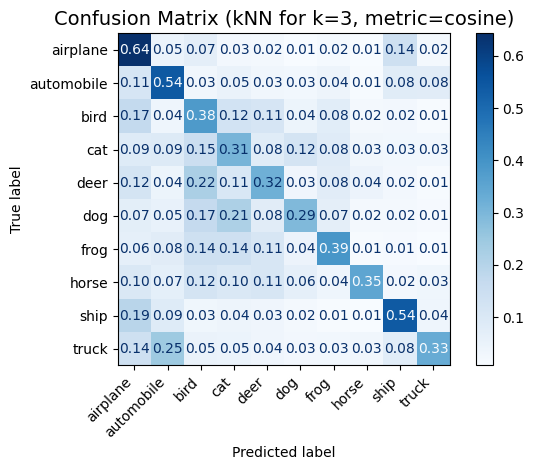

In [5]:
# K-Nearest Neighbors for k=1 and Cosine distance
knn_cosine, y_pred_knn_cosine, test_accuracy_knn_cosine = train_knn(
    x_train, y_train, x_test, y_test, k=1, metric='cosine')

knn_results(y_test, y_pred_knn_cosine, class_names, k=1, metric='cosine')

# K-Nearest Neighbors for k=3 and Cosine distance
knn_3_cosine, y_pred_knn_3_cosine, test_accuracy_knn_3_cosine = train_knn(
    x_train, y_train, x_test, y_test, k=3, metric='cosine')

knn_results(y_test, y_pred_knn_3_cosine, class_names, k=3, metric='cosine')

**Manhattan distance:**

K-Nearest Neighbors Classifier for k=1 and manhattan distance
Training time: 0.01 seconds
Testing time: 44.28 seconds
Training accuracy: 100.00%
Test accuracy: 38.91%


====== Classification Report (kNN for k=1, metric=manhattan) ======:
              precision    recall  f1-score   support

    airplane       0.44      0.53      0.48      1000
  automobile       0.57      0.34      0.42      1000
        bird       0.27      0.40      0.32      1000
         cat       0.31      0.22      0.26      1000
        deer       0.29      0.43      0.34      1000
         dog       0.39      0.28      0.33      1000
        frog       0.34      0.47      0.39      1000
       horse       0.56      0.38      0.45      1000
        ship       0.46      0.57      0.51      1000
       truck       0.56      0.28      0.37      1000

    accuracy                           0.39     10000
   macro avg       0.42      0.39      0.39     10000
weighted avg       0.42      0.39      0.39     10000



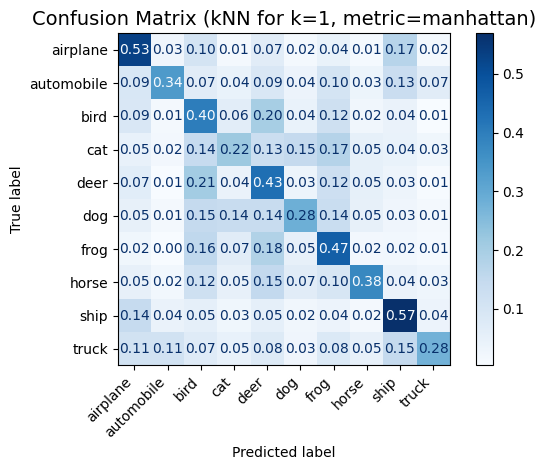

K-Nearest Neighbors Classifier for k=3 and manhattan distance
Training time: 0.01 seconds
Testing time: 47.37 seconds
Training accuracy: 62.88%
Test accuracy: 37.50%


====== Classification Report (kNN for k=3, metric=manhattan) ======:
              precision    recall  f1-score   support

    airplane       0.33      0.63      0.43      1000
  automobile       0.50      0.39      0.44      1000
        bird       0.24      0.49      0.32      1000
         cat       0.29      0.21      0.24      1000
        deer       0.30      0.42      0.35      1000
         dog       0.48      0.21      0.29      1000
        frog       0.39      0.39      0.39      1000
       horse       0.71      0.28      0.41      1000
        ship       0.53      0.54      0.54      1000
       truck       0.74      0.19      0.30      1000

    accuracy                           0.38     10000
   macro avg       0.45      0.38      0.37     10000
weighted avg       0.45      0.38      0.37     10000



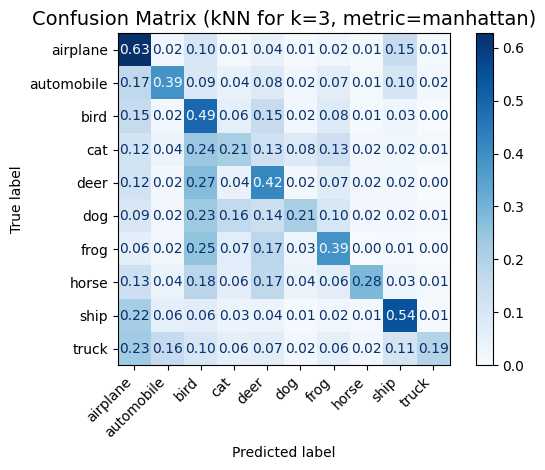

In [6]:
# K-Nearest Neighbors for k=1 and Manhattan distance
knn_manhattan, y_pred_knn_manhattan, test_accuracy_knn_manhattan = train_knn(
    x_train, y_train, x_test, y_test, k=1, metric='manhattan')

knn_results(y_test, y_pred_knn_manhattan, class_names, k=1, metric='manhattan')

# K-Nearest Neighbors for k=3 and Manhattan distance
knn_3_manhattan, y_pred_knn_3_manhattan, test_accuracy_knn_3_manhattan = train_knn(
    x_train, y_train, x_test, y_test, k=3, metric='manhattan')

knn_results(y_test, y_pred_knn_3_manhattan, class_names, k=3, metric='manhattan')

##### ***Nearest Class Centroid***
**Euclidean distance:**

Nearest Class Centroid (NCC) Classifier for euclidean distance
Training time: 0.06 seconds
Testing time: 0.04 seconds
Training accuracy: 26.77%
Test accuracy: 27.61%


====== Classification Report (NCC for metric=euclidean) ======:
              precision    recall  f1-score   support

    airplane       0.27      0.54      0.36      1000
  automobile       0.28      0.18      0.22      1000
        bird       0.29      0.11      0.16      1000
         cat       0.26      0.05      0.09      1000
        deer       0.27      0.12      0.16      1000
         dog       0.27      0.29      0.28      1000
        frog       0.21      0.53      0.31      1000
       horse       0.26      0.17      0.20      1000
        ship       0.42      0.37      0.39      1000
       truck       0.33      0.41      0.36      1000

    accuracy                           0.28     10000
   macro avg       0.29      0.28      0.25     10000
weighted avg       0.29      0.28      0.25     10000



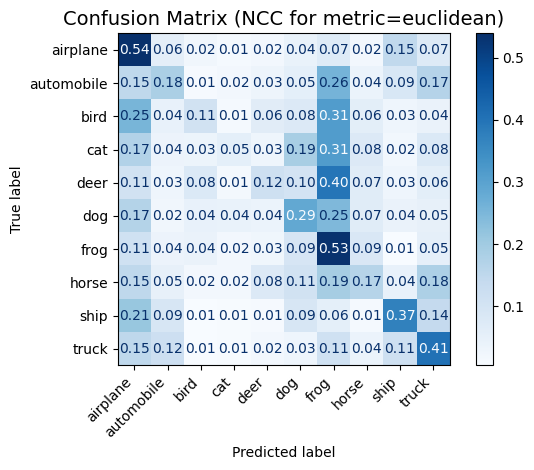

In [7]:
# Nearest Class Centroid for Euclidean distance
ncc, y_pred_ncc, test_accuracy_ncc = train_ncc(
    x_train, y_train, x_test, y_test, metric='euclidean')

ncc_results(y_test, y_pred_ncc, class_names, metric='euclidean')

**Manhattan distance:**

Nearest Class Centroid (NCC) Classifier for manhattan distance
Training time: 0.08 seconds
Testing time: 0.02 seconds
Training accuracy: 27.90%
Test accuracy: 28.47%


====== Classification Report (NCC for metric=manhattan) ======:
              precision    recall  f1-score   support

    airplane       0.27      0.49      0.35      1000
  automobile       0.30      0.26      0.28      1000
        bird       0.24      0.10      0.14      1000
         cat       0.21      0.07      0.11      1000
        deer       0.29      0.19      0.23      1000
         dog       0.27      0.27      0.27      1000
        frog       0.24      0.44      0.31      1000
       horse       0.26      0.21      0.23      1000
        ship       0.41      0.42      0.42      1000
       truck       0.33      0.39      0.36      1000

    accuracy                           0.28     10000
   macro avg       0.28      0.28      0.27     10000
weighted avg       0.28      0.28      0.27     10000



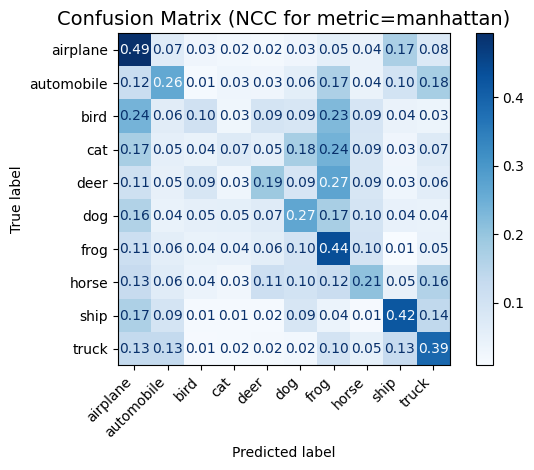

In [8]:
# Nearest Class Centroid for Manhattan distance
ncc_manhattan, y_pred_ncc_manhattan, test_accuracy_ncc_manhattan = train_ncc(
    x_train, y_train, x_test, y_test, metric='manhattan')

ncc_results(y_test, y_pred_ncc_manhattan, class_names, metric='manhattan')

**K-Nearest Neighbors VS Nearest Class Centroid:**

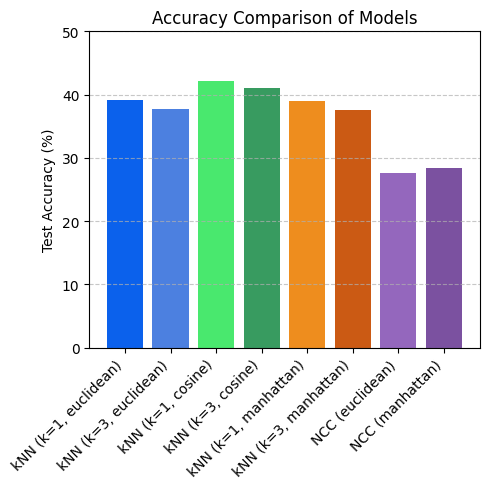

In [9]:
# Collect test accuracies for comparison
accuracies = {
    'kNN (k=1, euclidean)': test_accuracy_knn,
    'kNN (k=3, euclidean)': test_accuracy_knn_3,
    'kNN (k=1, cosine)': test_accuracy_knn_cosine,
    'kNN (k=3, cosine)': test_accuracy_knn_3_cosine,
    'kNN (k=1, manhattan)': test_accuracy_knn_manhattan,
    'kNN (k=3, manhattan)': test_accuracy_knn_3_manhattan,
    'NCC (euclidean)': test_accuracy_ncc,
    'NCC (manhattan)': test_accuracy_ncc_manhattan
}

colors = [
    "#0b61ec", "#4c80e0",   # Euclidean (blue shades)
    "#49e86e", "#389b60",   # Cosine (green shades)
    "#ee8d1e", "#cb5a14",   # Manhattan (orange shades)
    '#9467bd', '#7b51a0'    # NCC (purple shades)
]

# Plot the accuracies
plt.figure(figsize=(5, 5))
plt.bar(accuracies.keys(), accuracies.values(), color=colors)
plt.ylabel('Test Accuracy (%)')
plt.title('Accuracy Comparison of Models')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 50)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
